### Cell 1: นำเข้า Library ที่จำเป็น
เซลล์นี้ทำหน้าที่เรียกใช้เครื่องมือต่างๆ ที่จำเป็นสำหรับการทำงาน:
- `os`: สำหรับจัดการเส้นทางไฟล์และโฟลเดอร์
- `pandas` และ `numpy`: สำหรับจัดการตารางข้อมูล (Dataframe) และการคำนวณตัวเลข
- `matplotlib` และ `seaborn`: สำหรับสร้างกราฟและ Visualization ทั้ง 3 รูปแบบ
- `warnings`: ปิดการแจ้งเตือนจุกจิกเพื่อความสะอาดของ Output

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
import os

# ปิดการแจ้งเตือน (Warnings) ที่ไม่จำเป็นเพื่อให้ Output อ่านง่ายขึ้น
warnings.filterwarnings('ignore')

### Cell 2: ฟังก์ชันสำหรับ Data Processing & Cleaning
เซลล์นี้ประกอบด้วย 2 ฟังก์ชันหลัก:
1. `clean_taxonomy`: รับ Taxonomy string เข้ามาตัดแบ่งด้วยเครื่องหมาย `;` หรือ `.` จากนั้นเช็คว่าระดับ Rank ที่เราต้องการมันคือ "uncultured", "unknown" ฯลฯ หรือไม่ ถ้าใช่ จะถอยกลับไปหา Rank ที่สูงกว่าที่ระบุชื่อได้ พร้อมใส่วงเล็บกำกับไว้ เช่น `Armatimonadota (p)`
2. `process_microbiome_data`: โหลดไฟล์ทั้งสองไฟล์ คำนวณ `% Relative Abundance` กรองข้อมูลด้วยค่า Cut-off ที่ผู้ใช้กำหนด และนำข้อมูล Feature กับ LEfSe มาผสานกันเพื่อให้มั่นใจว่าเรามีข้อมูลครบถ้วนสำหรับการสร้างกราฟ

In [15]:
def clean_taxonomy(taxa_string, target_rank='g', sep=';'):
    """
    ฟังก์ชันทำความสะอาด Taxonomy String รองรับการ Fallback ไปยัง Rank ที่สูงกว่า
    หากพบคำที่ไม่สามารถระบุได้ เช่น 'Incertae_Sedis', 'uncultured', หรือ 'unknown'
    """
    ranks = ['d', 'p', 'c', 'o', 'f', 'g']
    if target_rank not in ranks:
        raise ValueError(f"Invalid rank. โปรดเลือกจาก {ranks}")
    
    # แยก Taxonomy string ด้วยเครื่องหมายที่กำหนด (เช่น ; สำหรับ Feature, . สำหรับ LEfSe)
    parts = str(taxa_string).split(sep)
    taxa_dict = {}
    
    # ดึงข้อมูลจาก format rank__name เข้าเก็บใน Dictionary
    for part in parts:
        if '__' in part:
            try:
                r, name = part.split('__', 1)
                if r == 'k': r = 'd' # อนุโลมใช้ k (Kingdom) แทน d (Domain)
                taxa_dict[r.strip()] = name.strip()
            except ValueError:
                continue
                
    target_idx = ranks.index(target_rank)
    invalid_keywords = ['uncultured', 'unknown', 'incertae_sedis', 'incertae sedis']
    
    # ถอยหลังเช็คจาก Target Rank ไปจนถึง Domain เพื่อหาชื่อที่ระบุได้
    for i in range(target_idx, -1, -1):
        r = ranks[i]
        name = taxa_dict.get(r, '')
        
        # ตรวจสอบว่าเป็นคำที่ไม่มีความหมาย (invalid) หรือไม่
        is_invalid = (name == '') or any(kw in name.lower() for kw in invalid_keywords)
        
        if not is_invalid:
            if i == target_idx:
                return name # คืนค่าชื่อปกติถ้าระบุได้ใน Rank ที่ต้องการ
            else:
                return f"{name} ({r})" # ถ้าต้องถอยกลับ ให้ใส่วงเล็บ Rank นั้นๆ เช่น (p)
                
    return "Unknown"

def process_microbiome_data(feature_file, lefse_file, 
                            taxonomic_rank='g', 
                            percent_cutoff=0.1, 
                            lda_score_cutoff=2.0, 
                            p_value_cutoff=0.05):
    """
    ฟังก์ชันหลักสำหรับเตรียมข้อมูล คำนวณ % Relative Abundance และผสานกับข้อมูล LEfSe
    """
    # 1. จัดการข้อมูล Feature Table
    df_feat = pd.read_csv(feature_file)
    df_feat = df_feat.set_index(df_feat.columns[0]) # ตั้งคอลัมน์แรก (Sample ID) เป็น Index
    
    # ดึงคอลัมน์สุดท้ายมาเป็นข้อมูลกลุ่ม ไม่ว่าคอลัมน์นั้นจะชื่ออะไร (เช่น Group หรือ Agriculture_practice)
    groups = df_feat.iloc[:, -1]
    # แยกเอาเฉพาะข้อมูลตัวเลข Abundance (ดึงมาทุกคอลัมน์ยกเว้นคอลัมน์สุดท้าย)
    df_abund = df_feat.iloc[:, :-1]
    
    # คำนวณ % Relative Abundance: (Abundance ของ Taxa / ผลรวม Abundance ใน Sample นั้น) * 100
    df_rel = df_abund.div(df_abund.sum(axis=1), axis=0) * 100
    
    # ทำความสะอาดชื่อ Taxa โดยเรียกใช้ฟังก์ชัน clean_taxonomy (Separator ของข้อมูลนี้คือ ';')
    df_rel.columns = [clean_taxonomy(col, taxonomic_rank, sep=';') for col in df_rel.columns]
    # นำคอลัมน์ที่มีชื่อ Taxa เหมือนกัน (ผลจากการ Fallback) มารวมผลบวกเข้าด้วยกัน
    df_rel = df_rel.groupby(df_rel.columns, axis=1).sum()
    
    # กรองเอาเฉพาะ Taxa ที่มีค่าเฉลี่ย % Relative Abundance มากกว่าหรือเท่ากับ Cut-off
    mean_abund = df_rel.mean(axis=0)
    df_rel = df_rel.loc[:, mean_abund >= percent_cutoff]
    
    # 2. จัดการข้อมูล LEfSe
    df_lefse = pd.read_csv(lefse_file, sep='\t') # อ่านไฟล์ lefse.txt ด้วยการคั่นแบบ Tab
    
    # จัดการเปลี่ยนชื่อคอลัมน์ให้อ้างอิงง่ายขึ้น ป้องกัน Error จากชื่อคอลัมน์ที่ไม่ตรงเป๊ะๆ
    df_lefse.rename(columns={
        'Taxonomy / Feature': 'Taxa/Feature',
        'LDA score (log10)': 'LDA score'
    }, inplace=True)
    
    # แปลงข้อมูลตัวเลขให้แน่ใจว่าไม่มีข้อผิดพลาด (ถ้าเจอ '-' ปล่อยข้ามหรือแก้เป็น NaN แล้วลบออก)
    df_lefse['LDA score'] = pd.to_numeric(df_lefse['LDA score'], errors='coerce')
    df_lefse['p-value'] = pd.to_numeric(df_lefse['p-value'], errors='coerce')
    df_lefse = df_lefse.dropna(subset=['LDA score', 'p-value'])
    
    # กรองข้อมูล LEfSe ให้เหลือเฉพาะตัวที่ผ่าน Cut-off ของ LDA score และ p-value
    df_lefse = df_lefse[(df_lefse['LDA score'] >= lda_score_cutoff) & 
                        (df_lefse['p-value'] <= p_value_cutoff)]
    
    # ทำความสะอาดชื่อ Taxa ของไฟล์ LEfSe (Separator ของข้อมูลนี้คือ '.')
    df_lefse['Clean_Taxa'] = df_lefse['Taxa/Feature'].apply(lambda x: clean_taxonomy(x, taxonomic_rank, sep='.')).values
    
    # 3. หาส่วนร่วมของข้อมูลทั้ง 2 ตาราง (เก็บเฉพาะ Taxa ที่มีในทั้งคู่)
    valid_taxa = df_lefse['Clean_Taxa'].unique()
    common_taxa = [t for t in valid_taxa if t in df_rel.columns]
    
    # ตัดแบ่งตารางข้อมูลให้เหลือแค่ Taxa ที่ผ่านเงื่อนไข
    df_rel_filtered = df_rel[common_taxa]
    df_lefse_filtered = df_lefse[df_lefse['Clean_Taxa'].isin(common_taxa)]
    
    return df_rel_filtered, df_lefse_filtered, groups

### Cell 3: ฟังก์ชันสำหรับสร้าง Visualizations
เซลล์นี้มีหน้าที่วาดกราฟทั้ง 3 รูปแบบตาม Requirement พร้อมระบบสร้างโฟลเดอร์และเซฟภาพอัตโนมัติ:
1. **`plot_lefse_bar`**: กราฟแท่งแสดงค่า LDA Score โดยมีการแยกแกนซ้าย-ขวา ตามกลุ่ม Class (พ่นสีแบ่งกลุ่ม)
2. **`plot_microbiome_heatmap`**: แผนภาพความร้อน (Heatmap) ที่นำข้อมูล Relative Abundance มาดูแพทเทิร์น พร้อมทำ Clustering (แผนผังต้นไม้) และใส่แถบสีแยกกลุ่มตามข้อมูล Group
3. **`plot_bubble_chart`**: กราฟฟองสบู่ที่ใช้ขนาดฟองแทน % Relative abundance (แกน X คือ Samples, แกน Y คือ Taxa)

In [16]:
def plot_lefse_bar(df_lefse, save_format='png', output_dir='outputs'):
    """
    สร้าง LEfSe Plot แยกลักษณะแกน X บวก/ลบตาม Class
    """
    if df_lefse.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด LEfSe Plot")
        return
        
    plt.figure(figsize=(10, 8))
    # จัดการคอลัมน์ Class เอาเฉพาะที่มีค่า
    df_lefse_clean = df_lefse.dropna(subset=['Class'])
    classes = df_lefse_clean['Class'].unique()
    
    # ถ้ามี 2 Classes ให้กลับเครื่องหมาย (คูณ -1) ของกลุ่มนึง เพื่อให้แท่งกราฟชี้ไปฝั่งซ้าย
    if len(classes) == 2:
        class_1, class_2 = classes[0], classes[1]
        df_plot = df_lefse_clean.copy()
        df_plot.loc[df_plot['Class'] == class_2, 'LDA score'] *= -1
    else:
        df_plot = df_lefse_clean.copy()
        
    # เรียงลำดับข้อมูลจากน้อยไปมาก เพื่อความสวยงามของกราฟแท่ง
    df_plot = df_plot.sort_values('LDA score')
    
    # สร้างพจนานุกรมสี
    palette_colors = {classes[0]: 'green', classes[1]: 'red'} if len(classes) == 2 else None
    
    # วาดกราฟแท่ง (Barplot)
    if palette_colors:
        sns.barplot(x='LDA score', y='Clean_Taxa', hue='Class', data=df_plot, palette=palette_colors, dodge=False)
    else:
        sns.barplot(x='LDA score', y='Clean_Taxa', data=df_plot)
        
    plt.axvline(0, color='black', linewidth=1) # ลากเส้นแบ่งตรงกลาง (LDA = 0)
    
    # ตั้งชื่อกราฟและป้ายกำกับแกน
    plt.title('LEfSe LDA Scores', fontsize=16)
    plt.xlabel('LDA Score (log 10)', fontsize=12)
    plt.ylabel('Taxonomy', fontsize=12)
    plt.tight_layout()
    
    # สร้างโฟลเดอร์ outputs หากยังไม่มี และเซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'lefse_plot.{save_format}'), format=save_format, dpi=300)
    plt.show()

def plot_microbiome_heatmap(df_rel, groups, save_format='png', output_dir='outputs'):
    """
    สร้าง Heatmap แบบ Cluster โดยมีแถบสีบอกกลุ่ม Metadata (Farm Group)
    """
    if df_rel.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด Heatmap")
        return
        
    # เตรียมชุดสีสำหรับแบ่งกลุ่ม Samples (เช่น Chemical vs Organic)
    group_lut = dict(zip(groups.unique(), sns.color_palette("Set2", len(groups.unique()))))
    col_colors = groups.map(group_lut)
    col_colors.name = 'Group'
    
    # Transpose ข้อมูลเพื่อให้ Rows = Taxa, Columns = Samples ตามที่โจทย์กำหนด
    plot_data = df_rel.T 
    
    # สร้าง Clustermap (Heatmap แบบมี Dendrogram)
    g = sns.clustermap(plot_data,
                       cmap='YlGnBu', 
                       col_colors=col_colors, 
                       figsize=(12, 10),
                       standard_scale=0, # ปรับ Scale ตามแนวนอน (Taxa) ให้เห็นการกระจายตัวชัดขึ้น
                       linewidths=0.5,
                       yticklabels=True,
                       xticklabels=True)
                       
    g.fig.suptitle('Microbiome Abundance Heatmap', y=1.05, fontsize=16)
    
    # เพิ่มคำอธิบายสี (Legend) ของ Group ไว้ตรงกลางของแผนผัง
    for label, color in group_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
    g.ax_col_dendrogram.legend(loc="center", ncol=2)
    
    # เซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    g.savefig(os.path.join(output_dir, f'heatmap_plot.{save_format}'), format=save_format, dpi=300)
    plt.show()

def plot_bubble_chart(df_rel, save_format='png', output_dir='outputs'):
    """
    สร้าง Bubble Plot ขนาดฟองแปรผันตาม % Relative Abundance
    """
    if df_rel.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด Bubble Plot")
        return
        
    # แปลงรูปแบบตารางจากแบบกว้าง (Wide) เป็นแบบยาว (Long) เพื่อให้วาดกราฟง่าย
    df_melt = df_rel.reset_index().melt(id_vars='index', var_name='Taxa', value_name='Abundance')
    df_melt.rename(columns={'index': 'Sample'}, inplace=True)
    
    # เอาเฉพาะจุดที่มีค่า Abundance > 0 (ประหยัดพื้นที่และไม่วาดฟองขนาด 0)
    df_melt = df_melt[df_melt['Abundance'] > 0]
    
    plt.figure(figsize=(14, 8))
    # วาด Bubble plot ด้วยฟังก์ชัน Scatterplot โดยกำหนดค่า size = 'Abundance'
    sns.scatterplot(data=df_melt, 
                    x='Sample', 
                    y='Taxa', 
                    size='Abundance', 
                    sizes=(20, 1000), # กำหนดช่วงขนาดของฟอง (เล็กสุด-ใหญ่สุด)
                    hue='Abundance', 
                    palette='viridis', 
                    alpha=0.7)
    
    plt.title('Relative Abundance Bubble Plot', fontsize=16)
    plt.xlabel('Samples', fontsize=12)
    plt.ylabel('Taxonomy', fontsize=12)
    plt.xticks(rotation=90)
    
    # ขยับกรอบ Legend ออกไปไว้นอกกราฟ
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rel. Abundance (%)')
    plt.tight_layout()
    
    # เซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'bubble_plot.{save_format}'), format=save_format, dpi=300)
    plt.show()

### Cell 4: ส่วนเรียกใช้งาน (Execution)
เซลล์นี้คือจุดที่เราจะเข้าไปแก้ไขค่า Parameter ต่างๆ เพื่อรันโปรแกรม:
- กำหนด `FEATURE_FILE` และ `LEFSE_FILE` ให้ชี้ไปที่ข้อมูลดิบในโฟลเดอร์ `inputs/`
- สามารถเปลี่ยนค่า Cut-off ได้อิสระตามการทดลอง เช่น `taxonomic_rank` (เลือกระดับ d, p, c, o, f, g), `% Cutoff`, `LDA score`, `p-value`
- เลือกว่าจะ Export เป็นรูปนามสกุล `png` หรือ `pdf` ได้ที่ตัวแปร `SAVE_FORMAT`

Data processing completed successfully!

Generating LEfSe Plot...


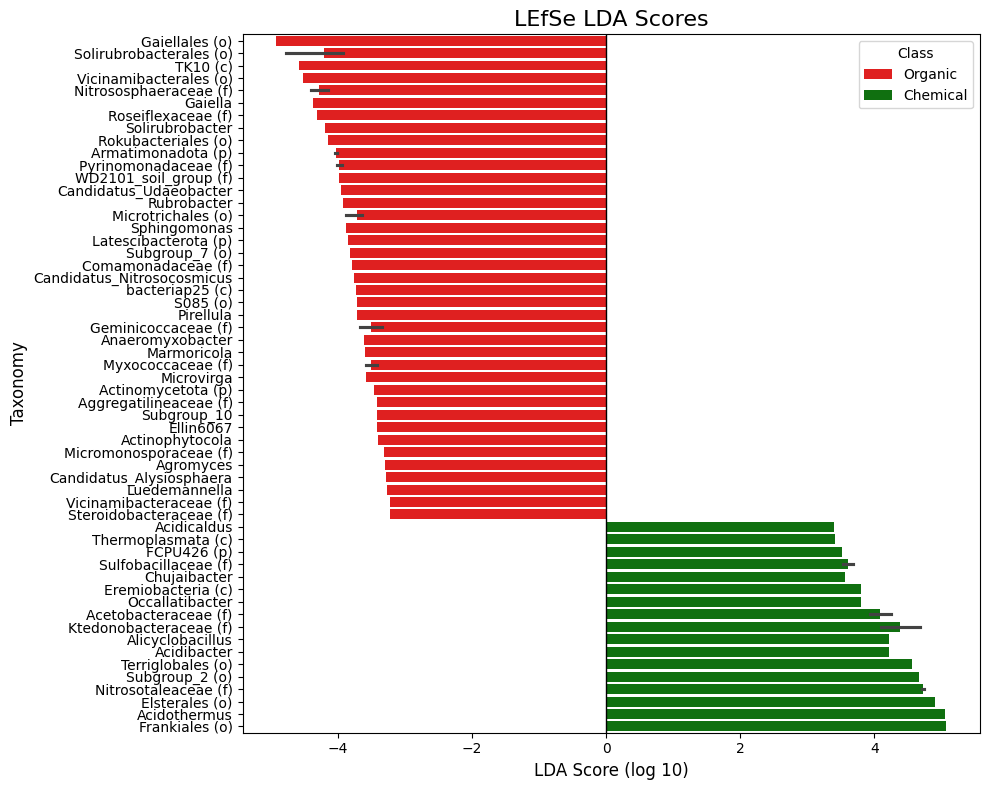

Generating Heatmap Plot...


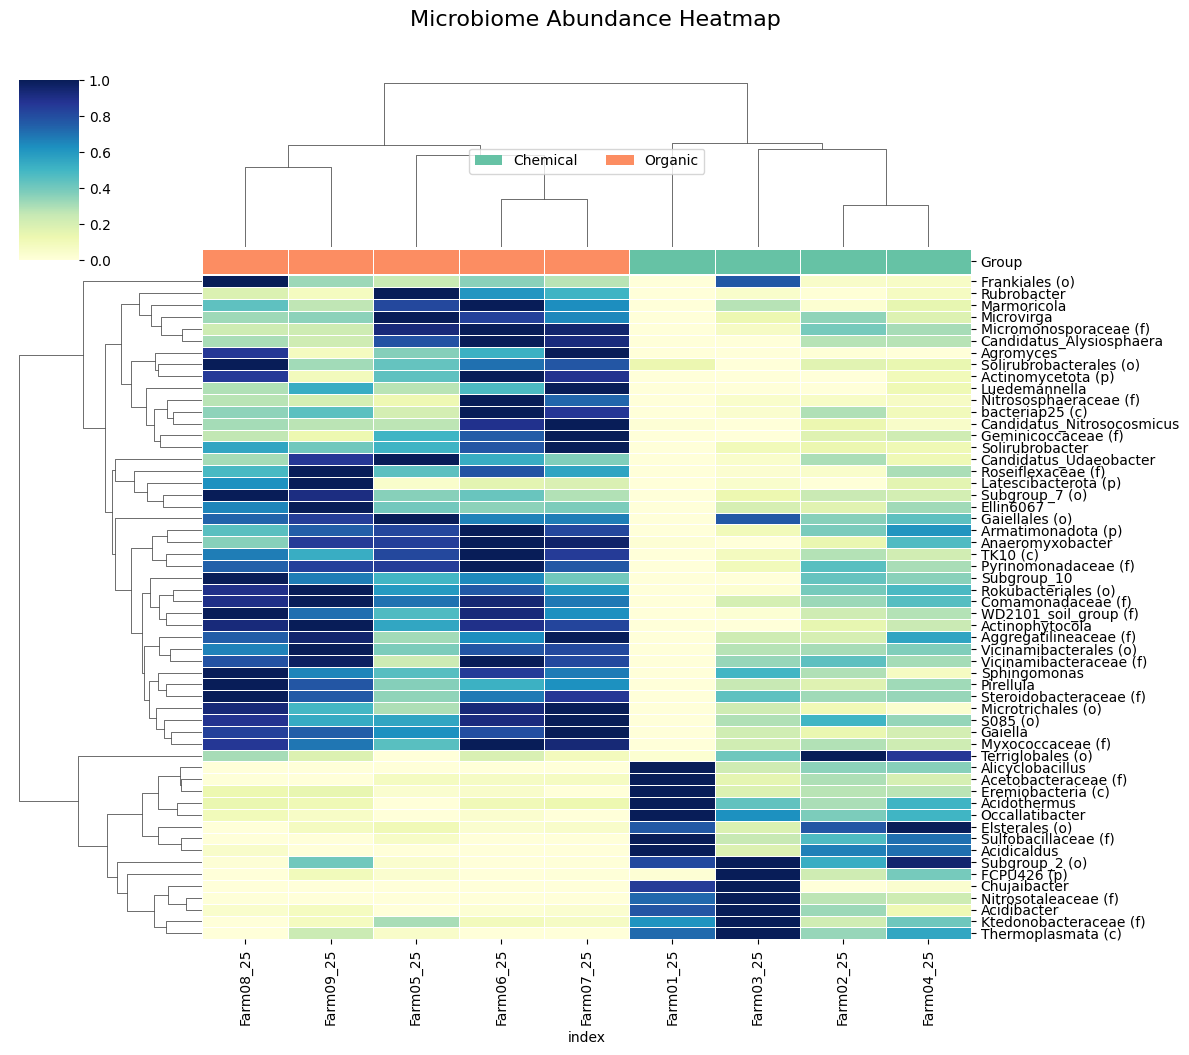

Generating Bubble Plot...


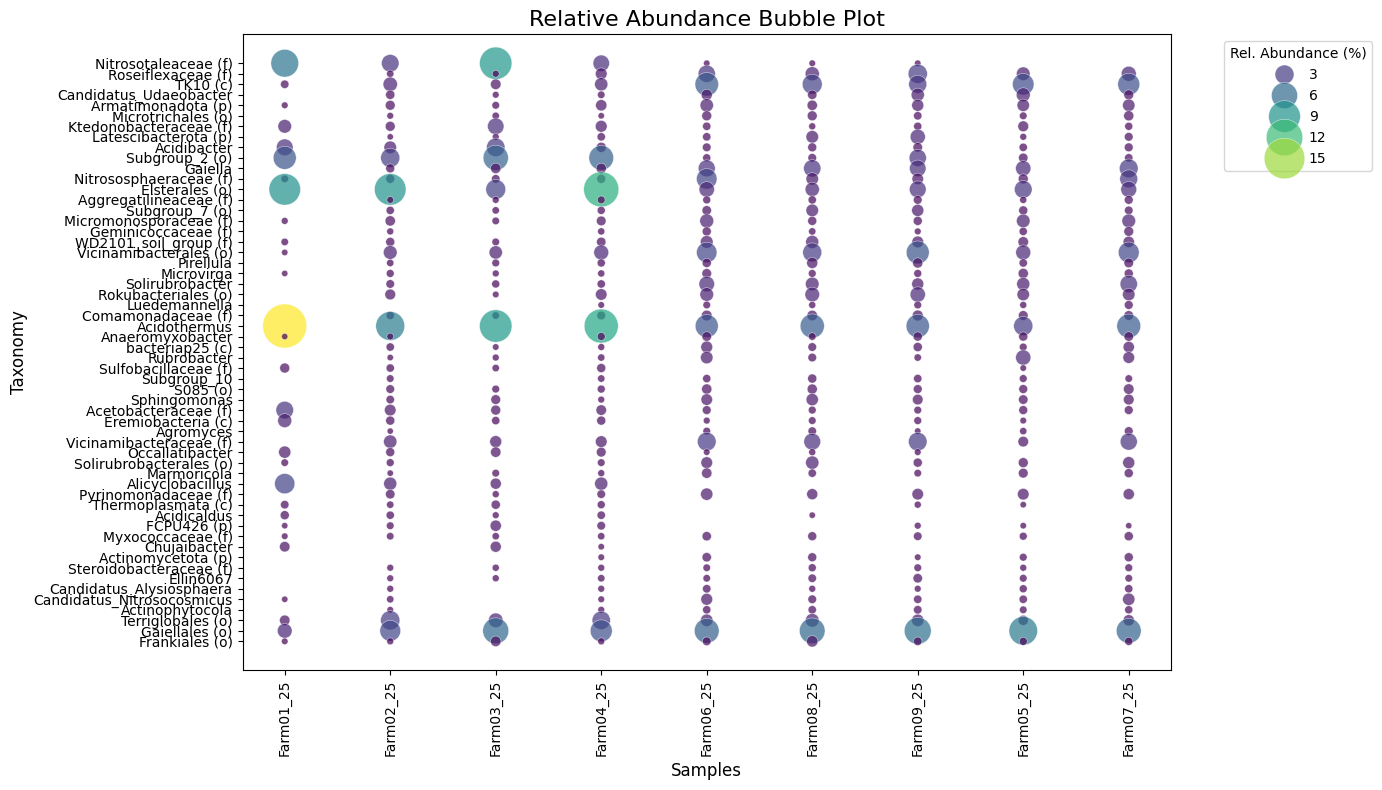

In [ ]:
# 1. กำหนดชื่อไฟล์ Input (ชี้ไปยังโฟลเดอร์ inputs/ ตามโครงสร้างโปรเจค)
FEATURE_FILE = 'inputs/feature_table.csv'
LEFSE_FILE = 'inputs/lefse.txt'
OUTPUT_DIR = 'outputs'

try:
    # 2. ประมวลผลข้อมูล (เรียกใช้ฟังก์ชันหลักเพื่อเตรียมข้อมูล)
    df_rel_filtered, df_lefse_filtered, sample_groups = process_microbiome_data(
        feature_file=FEATURE_FILE,
        lefse_file=LEFSE_FILE,
        taxonomic_rank='g',         # เลือกระดับ Rank (เช่น g = Genus, f = Family)
        percent_cutoff=0.1,         # ตัด Relative Abundance ที่น้อยกว่า 0.1% ทิ้ง
        lda_score_cutoff=3.0,       # ตัด LDA score ที่น้อยกว่า 2.0 ทิ้ง
        p_value_cutoff=0.05         # ตัด p-value ที่มากกว่า 0.05 ทิ้ง
    )
    
    print("Data processing completed successfully!")
    
    # 3. กำหนดนามสกุลไฟล์สำหรับการ Export กราฟ (รองรับ 'png' หรือ 'pdf')
    SAVE_FORMAT = 'png'
    
    # 4. สร้างและบันทึก Visualization ทั้ง 3 แบบ
    print("\nGenerating LEfSe Plot...")
    plot_lefse_bar(df_lefse_filtered, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR)
    
    print("Generating Heatmap Plot...")
    plot_microbiome_heatmap(df_rel_filtered, sample_groups, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR)
    
    print("Generating Bubble Plot...")
    plot_bubble_chart(df_rel_filtered, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR)

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("กรุณาตรวจสอบว่ามีไฟล์อยู่ในโฟลเดอร์ inputs/ หรือไม่")
except Exception as e:
    print(f"An unexpected error occurred: {e}")